In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, classification_report

# Add root to path
sys.path.append(str(Path.cwd().parent))

from src.data_loader import load_market_data
from src.features import build_feature_dataset
from src.train import create_model, backtest, evaluate_predictions

# Load data
df_raw = load_market_data()
data, predictors = build_feature_dataset(df_raw)

# Initialize and Backtest
model = create_model()
predictions = backtest(data, model, predictors, start=2500, step=250, threshold=0.6)

print("Backtest Complete.")
print(f"Total Prediction Days: {len(predictions)}")

Model Precision: 57.57%


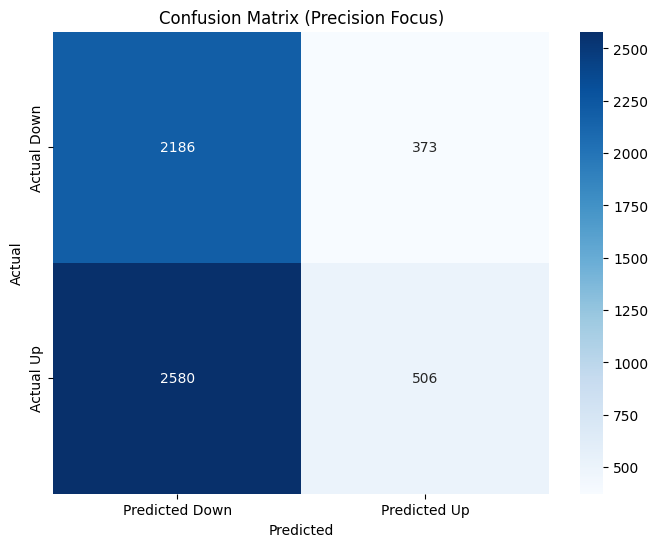


Detailed Metrics:
              precision    recall  f1-score   support

           0       0.46      0.85      0.60      2559
           1       0.58      0.16      0.26      3086

    accuracy                           0.48      5645
   macro avg       0.52      0.51      0.43      5645
weighted avg       0.52      0.48      0.41      5645



In [ ]:
# Calculate basic precision
metrics = evaluate_predictions(predictions)
print(f"Model Precision: {metrics['precision']:.2%}")

# Create Confusion Matrix
cm = confusion_matrix(predictions["Target"], predictions["Predictions"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title("Confusion Matrix (Precision Focus)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Classification Report
print("\nDetailed Metrics:")
print(classification_report(predictions["Target"], predictions["Predictions"], zero_division=0))

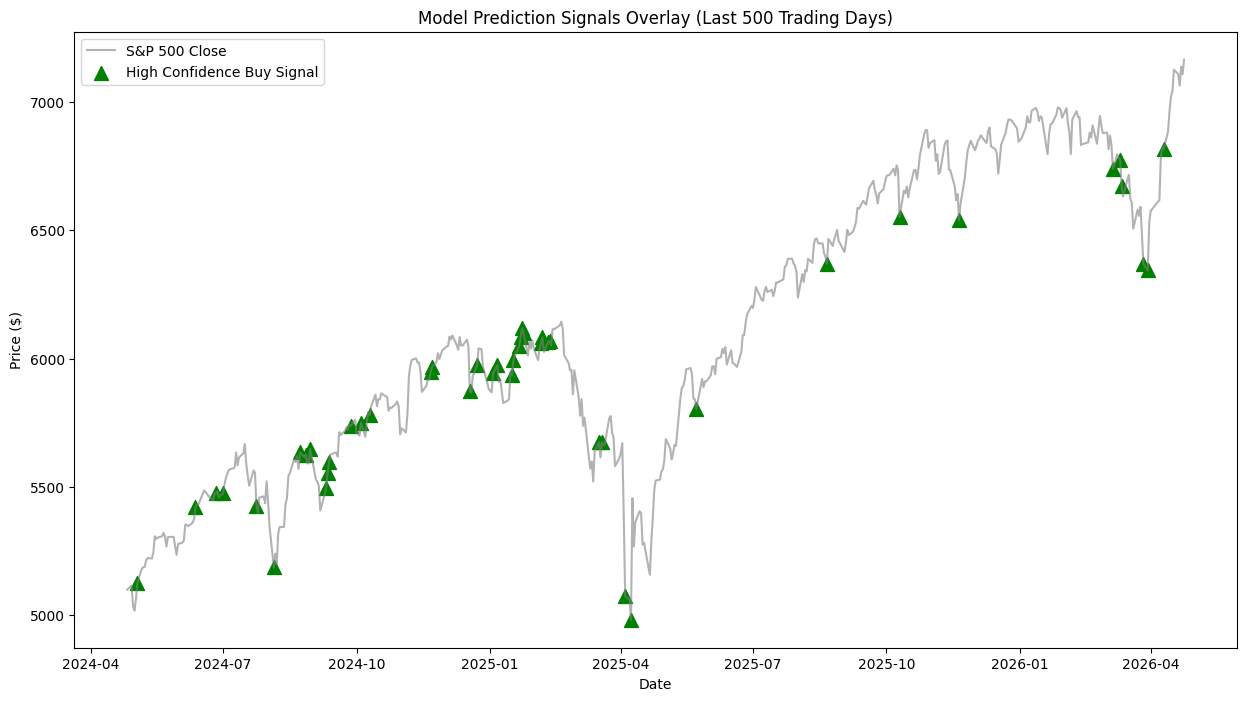

In [ ]:
# Merge predictions back with the close price for plotting
plot_df = predictions.merge(data[['Close']], left_index=True, right_index=True)

# Let's look at the last 2 years for clarity
recent_plot = plot_df.tail(500) 

plt.figure(figsize=(15, 8))
plt.plot(recent_plot.index, recent_plot['Close'], label='S&P 500 Close', alpha=0.6, color='gray')

# Identify "Buy" signals (where prediction was 1)
buys = recent_plot[recent_plot['Predictions'] == 1]

plt.scatter(buys.index, buys['Close'], marker='^', color='green', s=100, label='High Confidence Buy Signal')

plt.title("Model Prediction Signals Overlay (Last 500 Trading Days)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

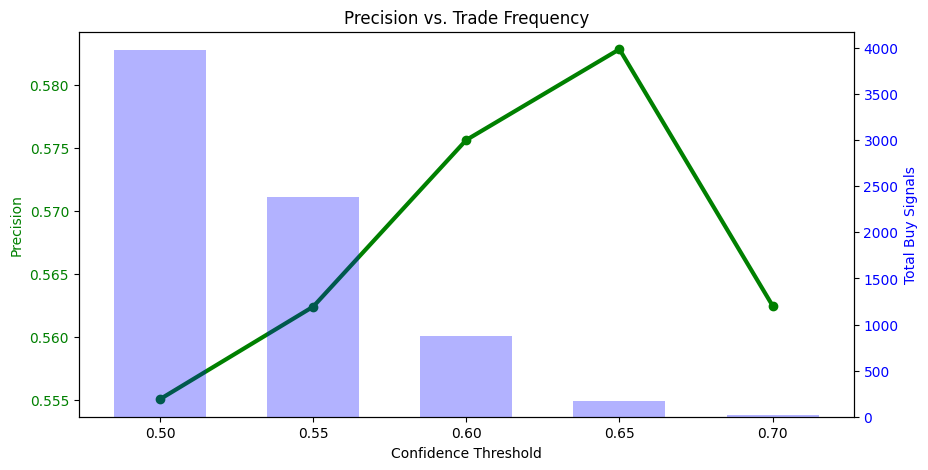

In [ ]:
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7]
results = []

for t in thresholds:
    # Use the probabilities we already saved in the backtest
    t_preds = (predictions["Probability"] >= t).astype(int)
    prec = precision_score(predictions["Target"], t_preds, zero_division=0)
    count = t_preds.sum()
    results.append({"Threshold": t, "Precision": prec, "Trade_Count": count})

thresh_df = pd.DataFrame(results)

# Plotting the trade-off
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Precision', color='green')
ax1.plot(thresh_df['Threshold'], thresh_df['Precision'], marker='o', color='green', linewidth=3)
ax1.tick_params(axis='y', labelcolor='green')

ax2 = ax1.twinx()
ax2.set_ylabel('Total Buy Signals', color='blue')
ax2.bar(thresh_df['Threshold'], thresh_df['Trade_Count'], alpha=0.3, color='blue', width=0.03)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Precision vs. Trade Frequency")
plt.show()